# Feature engineering - VNExpress News Dataset

Việc chúng ta mã hóa các văn bản, ta chỉ mới sử dụng các trường văn bản, tiếp sau đây
chúng ta thực hiện việc trích xuất các đặc trưng ở các trường còn lại

Notebook này thực hiện việc trích xuất đặc trưng ở các mục:

1. Metadata
2. Thời gian
3. Author
4. Visualization những đặc trưng đã trích xuất

Load dữ liệu được encode từ trước

In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv(r"..\\data\\vnexpress_clean_data.csv")

# Gộp text
df["full_text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["content"].fillna("")
)

# Load vectorizer và encode
with open("..\\data\\vietnamese-stopwords.txt", encoding="utf-8") as f:
    vietnamese_stopwords = f.read().splitlines()

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-zA-ZÀ-ỹ_]+\b",
    stop_words=vietnamese_stopwords
)

X_text = vectorizer.fit_transform(df["full_text"])
print("TF-IDF matrix shape:", X_text.shape)

# Label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["group"])

print(f"Classes: {label_encoder.classes_}")
print(f"Target distribution:\n{np.bincount(y)}")

c:\Users\nguye\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['a', 'bao', 'bay', 'biến', 'biệt', 'bây', 'bõm', 'bảo', 'bất', 'bẩy', 'bập', 'bắt', 'bội', 'chao', 'chi', 'chia', 'chu', 'chui', 'chuẩn', 'chà', 'chành', 'chí', 'chót', 'chùn', 'chăn', 'chũn', 'chưng', 'chạnh', 'chả', 'chầm', 'chầy', 'chập', 'chắn', 'chẳng', 'chết', 'chốc', 'chừ', 'chừng', 'coi', 'cu', 'cá', 'câu', 'cóc', 'công', 'cạnh', 'cảm', 'cầu', 'cật', 'cắt', 'cổ', 'cụ', 'cục', 'cực', 'da', 'dà', 'dĩ', 'dưng', 'dần', 'dầu', 'dịp', 'dở', 'dụng', 'gian', 'giá', 'giác', 'giời', 'ha', 'hiện', 'hoàn', 'hèn', 'hình', 'hô', 'hầu', 'hậu', 'hẳn', 'hồ', 'hỗ', 'hội', 'hợp', 'hự', 'khói', 'khô', 'khăn', 'khắc', 'khẳng', 'kia', 'kiện', 'kê', 'kì', 'kìa', 'kỳ', 'lai', 'le', 'liên', 'liệt', 'loạt', 'luận', 'luật', 'luốt', 'lình', 'lí', 'lô', 'lý', 'lập', 'lẽ', 'lị', '

TF-IDF matrix shape: (1214, 5000)
Classes: ['Giải trí' 'Sức khỏe']
Target distribution:
[602 612]


1. Trích xuất features từ Metadata

In [10]:
# ===== TEXT LENGTH =====
# đã có sẵn *_cleaned_length
df["title_length"] = df["title_cleaned_length"]
df["description_length"] = df["description_cleaned_length"]
df["content_length"] = df["content_cleaned_length"]

print("\n✓ Text length features:")
print(df[["title_length", "description_length", "content_length"]].describe())


# ===== WORD COUNT =====
df["title_words"] = df["title_cleaned"].fillna("").str.split().str.len()
df["description_words"] = df["description_cleaned"].fillna("").str.split().str.len()
df["content_words"] = df["content_cleaned"].fillna("").str.split().str.len()

print("\n✓ Word count features:")
print(df[["title_words", "description_words", "content_words"]].describe())


# ===== SENTENCE COUNT =====
df["title_sentences"] = df["title_cleaned"].fillna("").str.count(r"[.!?]") + 1
df["content_sentences"] = df["content_cleaned"].fillna("").str.count(r"[.!?]") + 1

print("\n✓ Sentence count features:")
print(df[["title_sentences", "content_sentences"]].describe())


# ===== DIGIT COUNT =====
df["title_digits"] = df["title_cleaned"].fillna("").str.count(r"\d")
df["content_digits"] = df["content_cleaned"].fillna("").str.count(r"\d")

print("\n✓ Digit count features:")
print(df[["title_digits", "content_digits"]].describe())


# ===== TAG FEATURES =====
# bạn đã có tags_count nên dùng trực tiếp
df["num_tags"] = df["tags_count"].fillna(0)

print("\n✓ Tags features:")
print(df["num_tags"].describe())


# ===== COMMENT FEATURES =====
print("\n✓ Comments feature:")
print(df["nums_of_comments"].describe())

# comment / độ dài bài
df["comment_density"] = (
    df["nums_of_comments"] / df["content_words"].replace(0,1)
)



✓ Text length features:
       title_length  description_length  content_length
count   1214.000000         1214.000000      1214.00000
mean      44.224053          128.565898      2753.11285
std       10.660119           24.140394      1299.44254
min       16.000000           71.000000         7.00000
25%       37.000000          112.000000      1976.75000
50%       44.000000          126.000000      2470.50000
75%       51.000000          142.000000      3200.75000
max       79.000000          220.000000      9842.00000

✓ Word count features:
       title_words  description_words  content_words
count  1214.000000        1214.000000    1214.000000
mean     10.262768          29.067545     611.939044
std       2.451706           5.723821     290.572842
min       4.000000          16.000000       2.000000
25%       9.000000          25.000000     437.000000
50%      10.000000          28.000000     547.000000
75%      12.000000          32.000000     712.750000
max      19.000000     

* `content_length` gần bằng `full_text_length` -> nội dung chi phối phần lớn thông tin của bài viết

* `content_words` khoảng 700 từ/bài -> dataset là long text nên TF-IDF hoạt động hiệu quả

* `content_sentences` có độ biến thiên lớn (8–125) -> độ dài bài viết có thể giúp phân biệt loại bài

* `digit_count` trung bình khá cao -> một số nhóm bài có thể đặc trưng bởi nhiều số liệu

* `num_tags` trung bình 3–4 -> tags có khả năng là feature dự đoán group khá mạnh

* `nums_of_comments` đa số bằng 0 -> feature này ít thông tin, có thể bỏ hoặc chuyển sang dạng binary

2. Trích xuất feature từ thời gian

Ta thấy các bài viết được lấy trong khoảng thời gian 3 tháng vào duy nhất năm 2026 nên
các đặc trưng về thời gian gần như không nói lên được gì nhiều

`day_of_week` có std khá thấp -> bài viết được đăng lên khá đều, nhưng đây có lẽ chỉ là KPI của nhân viên công ty
thôi

3. Trích xuất feature từ tác giả các bài đăng

In [12]:
# ===== Author Feature Engineering (Leakage-safe) =====

import pandas as pd
from sklearn.model_selection import train_test_split

# Train / Test split
X = df.drop(columns=["group"])
y = df["group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("DATA SPLIT")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Author article count (tính từ train)
author_counts = X_train["author"].value_counts()

X_train["author_article_count"] = X_train["author"].map(author_counts).fillna(0)
X_test["author_article_count"] = X_test["author"].map(author_counts).fillna(0)

print("\nAUTHOR ARTICLE COUNT STATISTICS")
print(X_train["author_article_count"].describe())

print("\nTop 5 most active authors:")
print(author_counts.head())

# Author specialization
author_group = pd.crosstab(X_train["author"], y_train)
author_group_ratio = author_group.div(author_group.sum(axis=1), axis=0)

print("\nAUTHOR SPECIALIZATION (sample)")
print(author_group_ratio.head())

# Map specialization sang dataset
for col in author_group_ratio.columns:

    feature_name = f"author_ratio_{col}"

    X_train[feature_name] = X_train["author"].map(
        author_group_ratio[col]
    ).fillna(0)

    X_test[feature_name] = X_test["author"].map(
        author_group_ratio[col]
    ).fillna(0)

print("\nSPECIALIZATION FEATURES CREATED:")
print([f"author_ratio_{c}" for c in author_group_ratio.columns])

# Kiểm tra feature cuối cùng
author_features = [c for c in X_train.columns if "author" in c]

print("\nFINAL AUTHOR FEATURES")
for f in author_features:
    print(f"- {f}")

print("\nFEATURE MATRIX SHAPE")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

DATA SPLIT
Train size: 971 | Test size: 243

AUTHOR ARTICLE COUNT STATISTICS
count    971.000000
mean      25.066941
std       19.460048
min        0.000000
25%        4.000000
50%       28.000000
75%       37.000000
max       64.000000
Name: author_article_count, dtype: float64

Top 5 most active authors:
author
Như Anh        64
Tân Cao        55
Phương Thảo    44
Lê Nga         41
Bình Minh      37
Name: count, dtype: int64

AUTHOR SPECIALIZATION (sample)
group                   Giải trí  Sức khỏe
author                                    
An Bình                      0.0       1.0
Anh Chi                      0.0       1.0
BSCKI Bế Thu Thủy            0.0       1.0
BSCKI Dương Quốc Trung       0.0       1.0
BSCKI Hoàng Đình Thành       0.0       1.0

SPECIALIZATION FEATURES CREATED:
['author_ratio_Giải trí', 'author_ratio_Sức khỏe']

FINAL AUTHOR FEATURES
- author_cleaned
- author
- author_article_count
- author_ratio_Giải trí
- author_ratio_Sức khỏe

FEATURE MATRIX SHAPE
Train: (9

`Author specialization` rất rõ ràng -> nhiều tác giả có tỉ lệ 1.0 cho 1 group, tức là 
tác giả đó chỉ viết cho group đó -> đặc trưng rất mạnh

4. Visualization


✓ Visualization Complete!


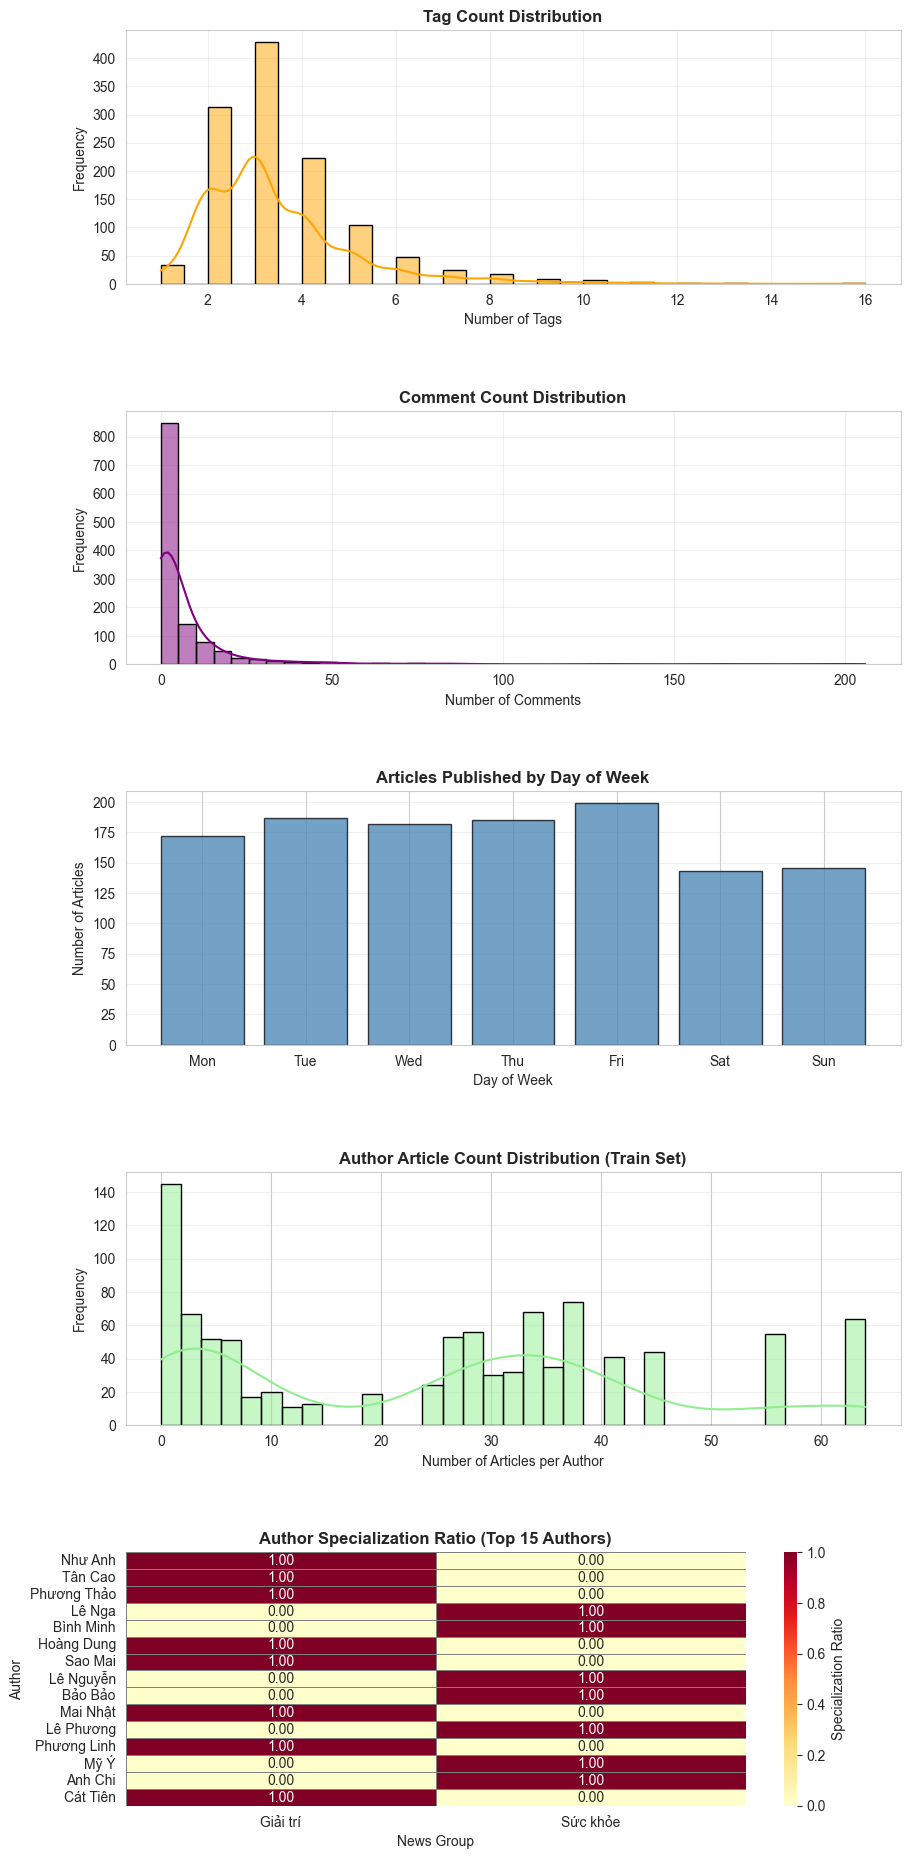

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig = plt.figure(figsize=(10, 28))
gs = fig.add_gridspec(6, 1, hspace=0.5)

# =========================================================
# 2. TAG DISTRIBUTION
# =========================================================

ax2 = fig.add_subplot(gs[0, 0])

sns.histplot(
    df["num_tags"],
    bins=30,
    kde=True,
    color="orange",
    edgecolor="black",
    ax=ax2
)

ax2.set_title("Tag Count Distribution", fontsize=12, fontweight='bold')
ax2.set_xlabel("Number of Tags")
ax2.set_ylabel("Frequency")
ax2.grid(alpha=0.3)

# =========================================================
# 3. COMMENT DISTRIBUTION
# =========================================================

ax3 = fig.add_subplot(gs[1, 0])

sns.histplot(
    df["nums_of_comments"],
    bins=40,
    kde=True,
    color="purple",
    edgecolor="black",
    ax=ax3
)

ax3.set_title("Comment Count Distribution", fontsize=12, fontweight='bold')
ax3.set_xlabel("Number of Comments")
ax3.set_ylabel("Frequency")
ax3.grid(alpha=0.3)

# =========================================================
# 4. ARTICLES BY DAY OF WEEK
# =========================================================

ax4 = fig.add_subplot(gs[2, 0])

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df["day_of_week"].value_counts().sort_index()

ax4.bar(
    range(len(day_counts)),
    day_counts.values,
    color="steelblue",
    edgecolor="black",
    alpha=0.75
)

ax4.set_xticks(range(7))
ax4.set_xticklabels(day_labels)

ax4.set_title("Articles Published by Day of Week", fontsize=12, fontweight='bold')
ax4.set_xlabel("Day of Week")
ax4.set_ylabel("Number of Articles")

ax4.grid(axis='y', alpha=0.3)

# =========================================================
# 5. AUTHOR ARTICLE COUNT
# =========================================================

ax5 = fig.add_subplot(gs[3, 0])

sns.histplot(
    X_train["author_article_count"],
    bins=35,
    kde=True,
    color="lightgreen",
    edgecolor="black",
    ax=ax5
)

ax5.set_title("Author Article Count Distribution (Train Set)", fontsize=12, fontweight='bold')
ax5.set_xlabel("Number of Articles per Author")
ax5.set_ylabel("Frequency")

ax5.grid(axis='y', alpha=0.3)

# =========================================================
# 6. AUTHOR SPECIALIZATION HEATMAP
# =========================================================

ax6 = fig.add_subplot(gs[4, 0])

top_authors = author_counts.head(15).index

sns.heatmap(
    author_group_ratio.loc[top_authors],
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Specialization Ratio'},
    ax=ax6
)

ax6.set_title("Author Specialization Ratio (Top 15 Authors)", fontsize=12, fontweight='bold')
ax6.set_xlabel("News Group")
ax6.set_ylabel("Author")
print("\n✓ Visualization Complete!")

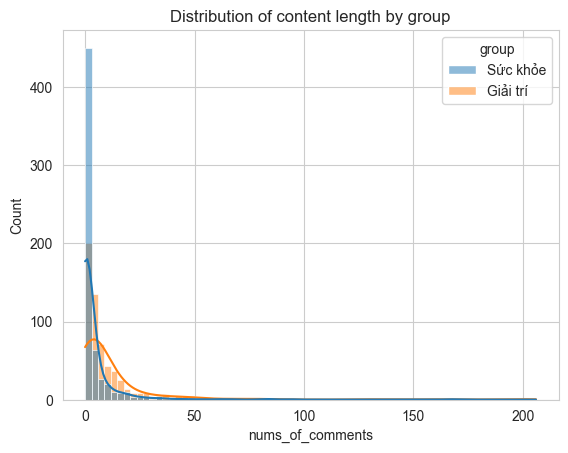

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="nums_of_comments",
    hue="group",
    kde=True
)

plt.title("Distribution of content length by group")
plt.show()


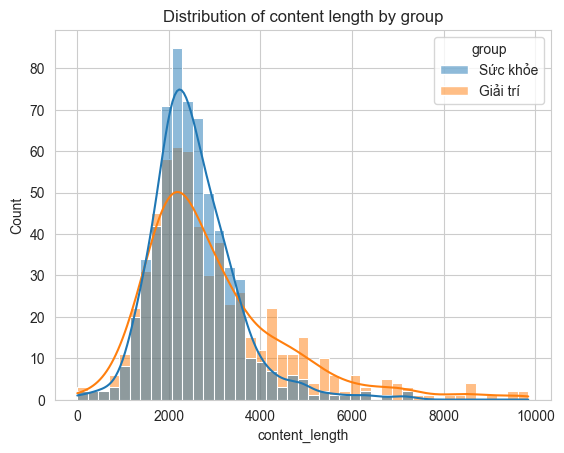

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="content_length",
    hue="group",
    kde=True
)

plt.title("Distribution of content length by group")
plt.show()


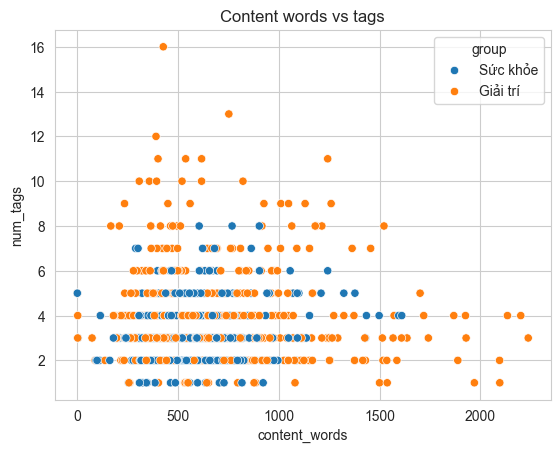

In [15]:
sns.scatterplot(
    data=df,
    x="content_words",
    y="num_tags",
    hue="group"
)

plt.title("Content words vs tags")
plt.show()


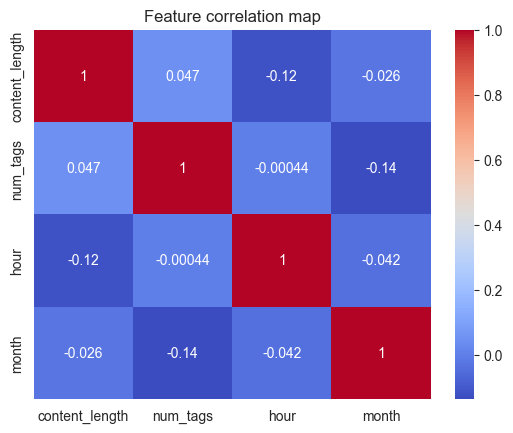

In [25]:
numeric_cols = [
    "content_length",
    "num_tags",
    "hour",
    "month"
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature correlation map")
plt.show()
